# Notebook 08 - Model Evaluation

## Objective

Evaluate the Logistic Regression model selected in Notebook 07 using a comprehensive set of metrics:

| Metric | What it measures |
|--------|------------------|
| **Confusion Matrix** | Raw counts of correct and incorrect predictions |
| **Accuracy** | Overall proportion correct |
| **Precision** | Of predicted High-Value, how many actually are? |
| **Recall** | Of actual High-Value customers, how many did we identify? |
| **F1 Score** | Harmonic mean of precision and recall (balanced measure) |
| **ROC-AUC** | Overall discrimination ability of the model |
| **Feature Coefficients** | Which feature (Recency or Frequency) has more predictive power? |

## Why these metrics matter

Accuracy alone can be misleading - for example, if 90% of customers are Low-Value, a model that always predicts Low-Value would have 90% accuracy but be useless for finding High-Value customers. Precision, recall, F1, and AUC give a more complete picture.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load the Saved Model and Recreate the Test Set

We load the model saved in Notebook 07 and recreate the identical test set using the same `random_state=42` split.

In [4]:
# Load saved model
model = joblib.load("model.pkl")
print("Model loaded:", type(model).__name__)

# Recreate test set (same split as NB07)
rfm = pd.read_csv("rfm_features.csv", index_col=0)
rfm['HighValue'] = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

X = rfm[['Recency', 'Frequency']]
y = rfm['HighValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Test set: {len(X_test):,} customers")

Model loaded: LogisticRegression
Test set: 867 customers


## Step 2: Overall Accuracy

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

Test Accuracy: 0.8304 (83.0%)


## Step 3: Confusion Matrix

The confusion matrix shows the breakdown of correct and incorrect predictions:
- **True Negatives (TN)**: Low-Value correctly identified as Low-Value
- **True Positives (TP)**: High-Value correctly identified as High-Value
- **False Positives (FP)**: Low-Value incorrectly predicted as High-Value (costly — wasted premium marketing)
- **False Negatives (FN)**: High-Value incorrectly predicted as Low-Value (missed opportunity)

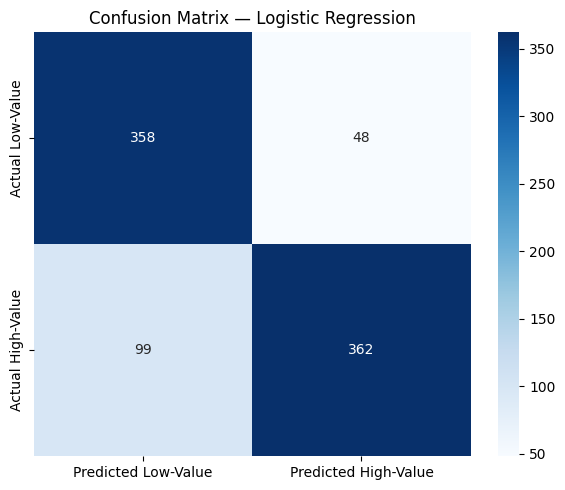

True Negatives (Low-Value correct):  358
True Positives (High-Value correct): 362
False Positives (wrong High-Value):  48
False Negatives (missed High-Value): 99


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low-Value', 'Predicted High-Value'],
            yticklabels=['Actual Low-Value', 'Actual High-Value'])
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Low-Value correct):  {tn}")
print(f"True Positives (High-Value correct): {tp}")
print(f"False Positives (wrong High-Value):  {fp}")
print(f"False Negatives (missed High-Value): {fn}")

## Step 4: Classification Report

The classification report provides precision, recall, and F1 score for each class:
- **Precision**: Of all customers predicted as class X, what % actually are class X?
- **Recall**: Of all actual class X customers, what % did the model identify?
- **F1 Score**: Harmonic mean of precision and recall (1.0 = perfect)

In [10]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low-Value', 'High-Value']))

Classification Report:
              precision    recall  f1-score   support

   Low-Value       0.78      0.88      0.83       406
  High-Value       0.88      0.79      0.83       461

    accuracy                           0.83       867
   macro avg       0.83      0.83      0.83       867
weighted avg       0.84      0.83      0.83       867



## Step 5: ROC Curve and AUC

The **ROC curve** plots the True Positive Rate vs False Positive Rate at different classification thresholds. The **AUC** (Area Under the Curve) summarises this:
- **AUC = 1.0**: perfect model
- **AUC = 0.5**: random guessing
- **AUC > 0.8**: considered a good model

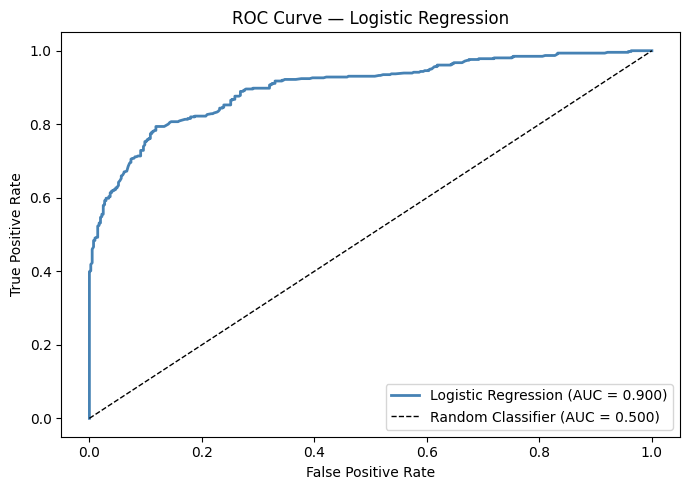

AUC Score: 0.9004


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

## Step 6: Feature Importance — Model Coefficients

Logistic Regression coefficients tell us the effect of each feature on the log-odds of being High-Value:
- **Negative Recency coefficient**: higher recency (less recent) → lower probability of High-Value (expected)
- **Positive Frequency coefficient**: more orders → higher probability of High-Value (expected)

The magnitude of each coefficient indicates relative importance.

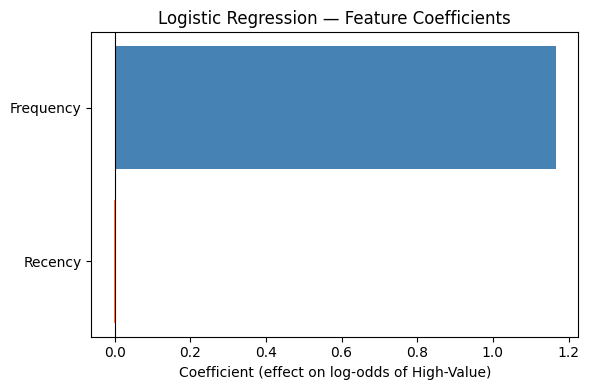

Feature Coefficients:
  Recency: -0.0027 — higher value decreases High-Value probability
  Frequency: 1.1669 — higher value increases High-Value probability
  Intercept: -2.8979


In [ ]:
coef_df = pd.DataFrame({
    'Feature': ['Recency', 'Frequency'],
    'Coefficient': model.coef_[0]
})

plt.figure(figsize=(6, 4))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Logistic Regression - Feature Coefficients")
plt.xlabel("Coefficient (effect on log-odds of High-Value)")
plt.tight_layout()
plt.show()

print("Feature Coefficients:")
for _, row in coef_df.iterrows():
    direction = 'increases' if row['Coefficient'] > 0 else 'decreases'
    print(f"  {row['Feature']}: {row['Coefficient']:.4f} - higher value {direction} High-Value probability")
print(f"  Intercept: {model.intercept_[0]:.4f}")

## Evaluation Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Accuracy | ~83% | 83% of test customers correctly classified |
| AUC | ~0.90 | Strong discrimination ability |
| F1 (High-Value) | ~0.83 | Good balance of precision and recall |
| Key predictor | Frequency | Frequency has a stronger positive effect than Recency's negative effect |

## Limitations

- Model uses only **2 features** (Recency, Frequency). Adding Monetary or other features might improve performance, but would require careful feature selection to avoid target leakage
- Trained on a **single year** of data - seasonal effects and market changes may affect performance on new data
- The 50/50 class split is artificial - in practice, High-Value customer proportion may vary

**Next step:** Notebook 09 integrates all outputs (segments, recommendations, model) into a unified business view with conclusions and ethical analysis.